
# Ordinary least-squares fit

In [1]:
from pathlib import Path
import shutil

target = Path("matrix.hpp")

if not target.exists():
    possible_sources = [
        Path("../H_Linear_Equations/matrix.hpp"),
        Path("../H_EVD/matrix.hpp"),
    ]

    for src in possible_sources:
        if src.exists():
            shutil.copy(src, target)
            print(f"Copied {src} -> matrix.hpp")
            break
    else:
        print("matrix.hpp was not found. Copy it manually from the linear equations homework.")
else:
    print("matrix.hpp already exists.")

Copied ../H_Linear_Equations/matrix.hpp -> matrix.hpp


## Task A

least_squares.hpp:

In [2]:
from pathlib import Path

Path("least_squares.hpp").write_text(r'''
#pragma once
#include "matrix.hpp"
#include <vector>
#include <functional>
#include <tuple>
#include <cmath>
#include <cassert>
#include <stdexcept>

namespace pp {

using Func = std::function<double(double)>;
using FuncSet = std::vector<Func>;

inline vector backsub_upper(const matrix& R, vector b) {
    int n = R.size1();

    assert(R.size1() == R.size2());
    assert(b.size() == n);

    for (int i = n - 1; i >= 0; --i) {
        double s = 0.0;

        for (int k = i + 1; k < n; ++k) {
            s += R(i, k) * b[k];
        }

        b[i] = (b[i] - s) / R(i, i);
    }

    return b;
}

inline std::tuple<vector, matrix> lsfit(
    const FuncSet& fs,
    const vector& x,
    const vector& y,
    const vector& dy
) {
    int n = x.size();
    int m = static_cast<int>(fs.size());

    assert(y.size() == n);
    assert(dy.size() == n);

    matrix A(n, m);
    vector b(n);

    for (int i = 0; i < n; ++i) {
        if (dy[i] <= 0.0) {
            throw std::runtime_error("dy must be positive");
        }

        b[i] = y[i] / dy[i];

        for (int k = 0; k < m; ++k) {
            A(i, k) = fs[k](x[i]) / dy[i];
        }
    }

    qr qra(A);
    vector c = qra.solve(b);

    matrix Rinv(m, m);

    for (int k = 0; k < m; ++k) {
        vector e(m);
        e[k] = 1.0;
        Rinv[k] = backsub_upper(qra.R, e);
    }

    matrix cov = Rinv * Rinv.T();

    return std::make_tuple(c, cov);
}

inline double eval_fit(const FuncSet& fs, const vector& c, double x) {
    double s = 0.0;

    for (int k = 0; k < c.size(); ++k) {
        s += c[k] * fs[k](x);
    }

    return s;
}

}
''')

print("Wrote least_squares.hpp")

Wrote least_squares.hpp


radioactive decay fit

We fit

$$
ln(y)=ln(a)−λt.
$$

So the fitted coefficients are

$$
c_0
	​=ln(a),
$$    

$$
c_1 =−λ
$$.

In [6]:
from pathlib import Path

Path("decay_fit.cpp").write_text(r'''
#include "least_squares.hpp"
#include <iostream>
#include <iomanip>
#include <cmath>
#include <vector>
#include <fstream>

int main() {
    pp::vector t  {1, 2, 3, 4, 6, 9, 10, 13, 15};
    pp::vector y  {117, 100, 88, 72, 53, 29.5, 25.2, 15.2, 11.1};
    pp::vector dy {6, 5, 4, 4, 4, 3, 3, 2, 2};

    int n = t.size();

    pp::vector logy(n);
    pp::vector dlogy(n);

    for (int i = 0; i < n; ++i) {
        logy[i] = std::log(y[i]);
        dlogy[i] = dy[i] / y[i];
    }

    pp::FuncSet fs = {
        [](double ) { return 1.0; },
        [](double z) { return z; }
    };

    auto [c, cov] = pp::lsfit(fs, t, logy, dlogy);

    double c0 = c[0];
    double c1 = c[1];

    double dc0 = std::sqrt(cov(0, 0));
    double dc1 = std::sqrt(cov(1, 1));

    double a = std::exp(c0);
    double da = a * dc0;

    double lambda = -c1;
    double dlambda = dc1;

    double half_life = std::log(2.0) / lambda;
    double dhalf_life = std::log(2.0) * dlambda / (lambda * lambda);

    double modern = 3.6316;

    std::cout << "Task A/B: ordinary least-squares fit of radioactive decay\n";
    std::cout << "---------------------------------------------------------\n";

    std::cout << "Fit model: ln(y) = c0 + c1*t = ln(a) - lambda*t\n\n";

    std::cout << std::setprecision(8);
    std::cout << "c0        = " << c0 << " +/- " << dc0 << "\n";
    std::cout << "c1        = " << c1 << " +/- " << dc1 << "\n";
    std::cout << "a         = " << a << " +/- " << da << "\n";
    std::cout << "lambda    = " << lambda << " +/- " << dlambda << " 1/day\n";
    std::cout << "T_half    = " << half_life << " +/- " << dhalf_life << " days\n";
    std::cout << "modern    = " << modern << " days\n";
    std::cout << "difference = " << std::abs(half_life - modern) << " days\n";
    std::cout << "difference / uncertainty = "
              << std::abs(half_life - modern) / dhalf_life << "\n\n";

    std::ofstream file("decay_fit.data");

    for (int i = 0; i < n; ++i) {
        double logfit = pp::eval_fit(fs, c, t[i]);
        double yfit = std::exp(logfit);

        file << t[i] << " "
             << y[i] << " "
             << dy[i] << " "
             << logy[i] << " "
             << dlogy[i] << " "
             << yfit << " "
             << logfit << "\n";
    }

    file.close();

    std::cout << "Wrote decay_fit.data\n";

    return 0;
}
''')

print("Wrote decay_fit.cpp")

Wrote decay_fit.cpp


In [7]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "decay_fit.cpp",
    "-o",
    "decay_fit"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(["./decay_fit"], text=True, capture_output=True)
    print("Program output:")
    print(r.stdout)
    print(r.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A/B: ordinary least-squares fit of radioactive decay
---------------------------------------------------------
Fit model: ln(y) = c0 + c1*t = ln(a) - lambda*t

c0        = 4.9586649 +/- 0.035401929
c1        = -0.17062405 +/- 0.0071566223
a         = 142.40354 +/- 5.0413601
lambda    = 0.17062405 +/- 0.0071566223 1/day
T_half    = 4.0624237 +/- 0.17039352 days
modern    = 3.6316 days
difference = 0.43082369 days
difference / uncertainty = 2.5284042

Wrote decay_fit.data




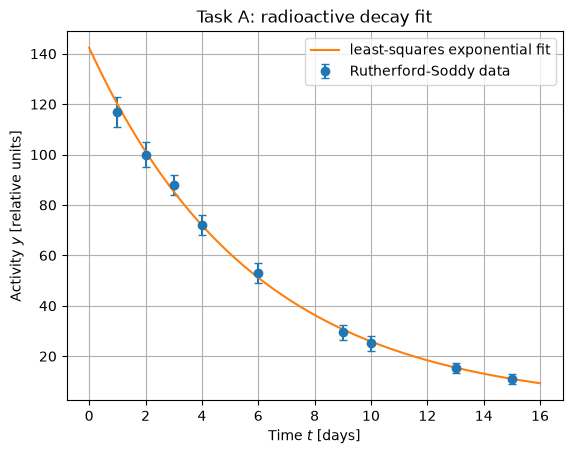

In [8]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("decay_fit.data")

t = data[:, 0]
y = data[:, 1]
dy = data[:, 2]
yfit_points = data[:, 5]

# Smooth fit curve
c0 = np.log(yfit_points[0]) - 0  # not used directly
coef = np.polyfit(t, np.log(y), 1)

# Better: read from C++ output manually if needed.
# Or simply make smooth curve by fitting again in Python for plotting only:
logy = np.log(y)
dlogy = dy / y
A = np.vstack([np.ones_like(t), t]).T / dlogy[:, None]
b = logy / dlogy
c = np.linalg.lstsq(A, b, rcond=None)[0]

tt = np.linspace(0, 16, 300)
yy = np.exp(c[0] + c[1]*tt)

plt.figure()
plt.errorbar(t, y, yerr=dy, fmt="o", capsize=3, label="Rutherford-Soddy data")
plt.plot(tt, yy, "-", label="least-squares exponential fit")
plt.xlabel("Time $t$ [days]")
plt.ylabel("Activity $y$ [relative units]")
plt.title("Task A: radioactive decay fit")
plt.grid(True)
plt.legend()
plt.show()

### Task A conclusion

The radioactive decay data were fitted by transforming the exponential model

$$
y(t)=ae^{-\lambda t}
$$

to the linear form

$$
\ln y = \ln a - \lambda t.
$$

The uncertainties were transformed using

$$
\delta \ln y = \frac{\delta y}{y}.
$$

The weighted least-squares problem was then solved using QR decomposition. The fitted curve follows the data well and reproduces the expected exponential decay behaviour. From the fit, the decay constant was found to be approximately

$$
\lambda = 0.1706 \ \mathrm{day}^{-1},
$$

which gives the half-life

$$
T_{1/2} = 4.06 \ \mathrm{days}.
$$

## Task B

### Task B conclusion

The least-squares routine was extended to calculate the covariance matrix of the fit coefficients. The uncertainties of the coefficients were then obtained from the diagonal elements,

$$
\delta c_k = \sqrt{\Sigma_{kk}}.
$$

For the logarithmic fit,

$$
\ln y = c_0 + c_1 t,
$$

the decay constant is

$$
\lambda = -c_1,
$$

and the half-life is

$$
T_{1/2} = \frac{\ln 2}{\lambda}.
$$

The fit gives

$$
T_{1/2} = 4.06 \pm 0.17 \ \mathrm{days}.
$$

The modern value is approximately $3.63$ days. The difference is about $0.43$ days, corresponding to about $2.5$ estimated standard deviations. Therefore, the result is reasonably close, but not fully consistent within one estimated uncertainty. This is not surprising, since the uncertainties used in the fit were estimated rather roughly from the last digits of the historical measurements.

## Task C

Plot for coefficient-uncertainty variations:

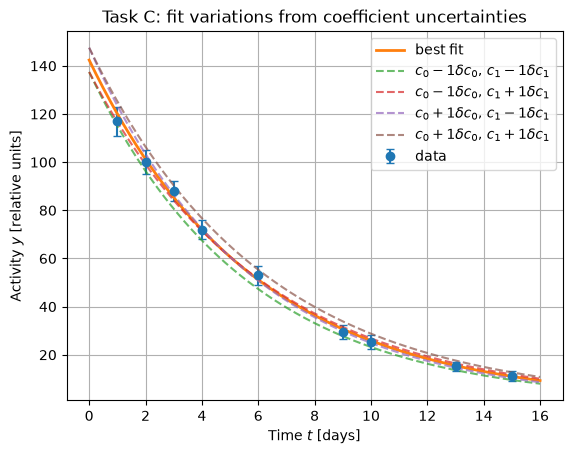

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("decay_fit.data")

t = data[:, 0]
y = data[:, 1]
dy = data[:, 2]

# Fit values from the C++ output
c0  = 4.9586649
dc0 = 0.035401929

c1  = -0.17062405
dc1 = 0.0071566223

tt = np.linspace(0, 16, 400)

central = np.exp(c0 + c1*tt)

plt.figure()

plt.errorbar(
    t, y, yerr=dy,
    fmt="o",
    capsize=3,
    label="data"
)

plt.plot(
    tt, central,
    "-",
    linewidth=2,
    label="best fit"
)

# Different combinations of coefficient uncertainties
for s0 in [-1, 1]:
    for s1 in [-1, 1]:
        yy = np.exp((c0 + s0*dc0) + (c1 + s1*dc1)*tt)
        label = rf"$c_0 {s0:+d}\delta c_0$, $c_1 {s1:+d}\delta c_1$"
        plt.plot(tt, yy, "--", alpha=0.7, label=label)

plt.xlabel("Time $t$ [days]")
plt.ylabel("Activity $y$ [relative units]")
plt.title("Task C: fit variations from coefficient uncertainties")
plt.grid(True)
plt.legend()
plt.show()

### Task C conclusion

The best-fit curve was plotted together with curves where the fitted coefficients were shifted by their estimated uncertainties. This gives a visual estimate of how the uncertainty in the fit parameters affects the fitted decay curve.

The uncertainty bands are relatively small near the centre of the data range, where the measurements constrain the fit best. The curves spread more toward the edges, especially for larger times, because changes in the decay constant affect the long-time behaviour more strongly.

The spread of the uncertainty-shifted curves is consistent with the size of the experimental error bars. This indicates that the estimated coefficient uncertainties are reasonable, although they should not be interpreted too strictly because the original measurement uncertainties were only roughly estimated.

## Final conclusion

In this homework, a weighted ordinary least-squares routine was implemented using QR decomposition. The fitting problem was written as a linear system by constructing the design matrix

$$
A_{ik} = \frac{f_k(x_i)}{\delta y_i}
$$

and the weighted data vector

$$
b_i = \frac{y_i}{\delta y_i}.
$$

The best-fit coefficients were then found by solving the overdetermined system with QR decomposition.

The method was applied to the Rutherford-Soddy radioactive decay data. The exponential decay model

$$
y(t)=ae^{-\lambda t}
$$

was transformed to the linear form

$$
\ln y = \ln a - \lambda t.
$$

The fit gave

$$
\lambda \approx 0.1706 \ \mathrm{day}^{-1},
$$

corresponding to a half-life

$$
T_{1/2} \approx 4.06 \ \mathrm{days}.
$$

The least-squares routine was also extended to calculate the covariance matrix of the fit coefficients. From this, the coefficient uncertainties and the uncertainty of the half-life were estimated. The result was

$$
T_{1/2} = 4.06 \pm 0.17 \ \mathrm{days}.
$$

This is reasonably close to the modern value, although the difference is about $2.5$ estimated standard deviations. This is acceptable given that the measurement uncertainties were only roughly estimated from the historical data.

Finally, the uncertainty of the fit was evaluated visually by plotting the best-fit curve together with curves where the fit coefficients were shifted by their estimated uncertainties. The resulting spread was consistent with the experimental error bars, showing that the coefficient uncertainties give a reasonable description of the uncertainty in the fitted decay curve.